# Customer Churn Prediction

## Objective
The goal of this project is to predict whether a customer will churn based on demographic and service usage data.

## Why This Matters
Customer churn directly impacts revenue. Identifying at-risk customers allows businesses to take proactive retention measures.

## Imports
Import required libraries for data analysis and visualisation.

In [1]:
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## Load Dataset
Load the Telco Customer Churn dataset into a DataFrame.

In [2]:
df = pd.read_csv("/content/Data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

## Data Overview
Understand the structure, data types, and completeness of the dataset.

In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Missing Values
Check for missing or inconsistent data.

In [6]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


## Target Variable (Churn)
Analyse the distribution of the target variable.

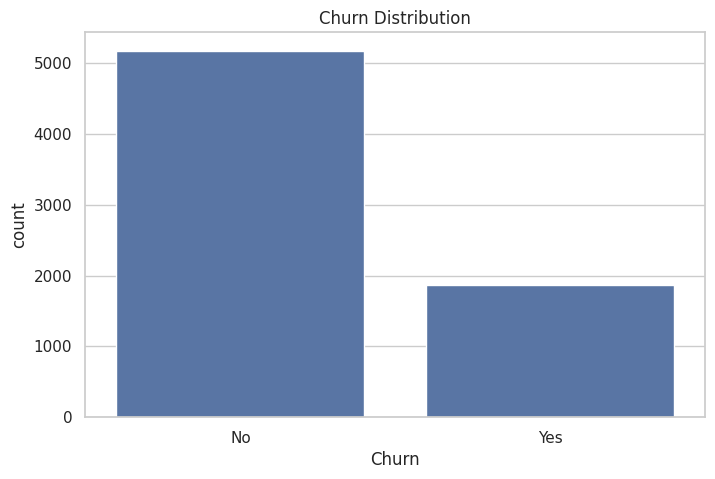

,proportion
Churn,
No,0.73463
Yes,0.26537


In [7]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

df["Churn"].value_counts(normalize=True)

### Insight
- The dataset is moderately imbalanced with approximately 26.5% churn rate.
- This indicates a moderate class imbalance which should be considered during modelling.

## Exploratory Data Analysis
Explore relationships between features and churn.

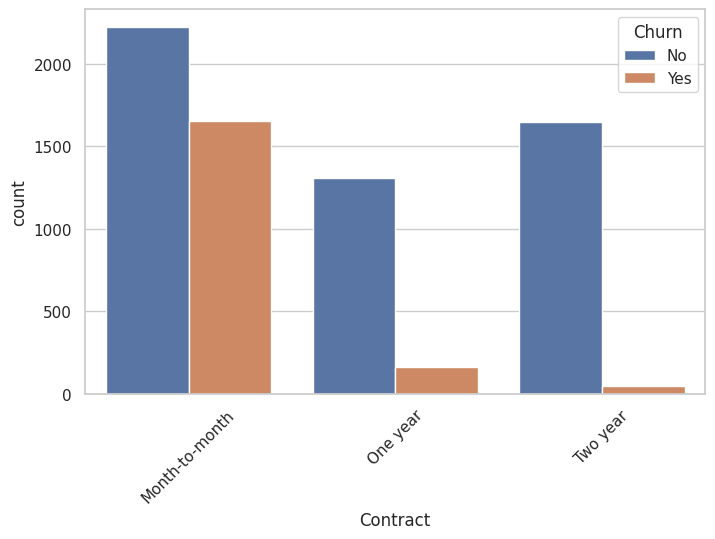

In [8]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.xticks(rotation=45)
plt.show()

### Observation:
- Customers on month-to-month contracts show significantly higher churn rates.

## Data Cleaning

In [9]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop missing values
df = df.dropna()

# Convert target to binary
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## Feature Engineering (Revised)
The previous encoding accidentally included `customerID`, creating ~7,000 meaningless columns. We drop it first, then encode only meaningful categorical features. We also scale numeric features so the logistic regression can converge properly.

In [10]:
from sklearn.preprocessing import StandardScaler

# Drop customerID — it's an identifier, not a feature
# (TotalCharges and Churn encoding already handled in Data Cleaning above)
df_clean = df.drop(columns=["customerID"])

# One-hot encode categorical columns
df_encoded = pd.get_dummies(df_clean, drop_first=True)

print(f"Feature matrix shape: {df_encoded.shape}")
print(f"Churn rate: {df_encoded['Churn'].mean():.1%}  ← class imbalance to handle")

Feature matrix shape: (7032, 31)
Churn rate: 26.6%  ← class imbalance to handle


## Train/Test Split with Scaling
We scale the numeric features so the logistic regression solver converges. `stratify=y` preserves the churn ratio in both splits.

In [11]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numeric features
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols])

print(f"Training set: {X_train.shape[0]} rows | Test set: {X_test.shape[0]} rows")
print(f"Churn rate in train: {y_train.mean():.1%} | test: {y_test.mean():.1%}")

Training set: 5625 rows | Test set: 1407 rows
Churn rate in train: 26.6% | test: 26.6%


## Model 1: Logistic Regression (Fixed)
Using `class_weight='balanced'` so the model accounts for the ~74/26 class split. This improves recall on the minority class (churners) (the group we care most about).

In [12]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr_model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


## Model 2: Random Forest (Comparison)
Tree-based models handle non-linear relationships and don't need scaling. We'll use this to compare with logistic regression and extract feature importances.

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


## Model Evaluation
Accuracy alone is misleading with imbalanced data (~26% churn rate). We evaluate using:
- **Precision/Recall/F1** — how well we identify actual churners
- **ROC-AUC** — overall discriminatory power across all thresholds
- **Confusion matrix** — visualise true/false positives and negatives

In [14]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("=" * 50)
print("LOGISTIC REGRESSION")
print("=" * 50)
print(classification_report(y_test, lr_preds, target_names=["No Churn", "Churn"]))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}\n")

print("=" * 50)
print("RANDOM FOREST")
print("=" * 50)
print(classification_report(y_test, rf_preds, target_names=["No Churn", "Churn"]))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_proba):.4f}")

LOGISTIC REGRESSION
              precision    recall  f1-score   support

    No Churn       0.90      0.70      0.79      1033
       Churn       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407

ROC-AUC: 0.8353

RANDOM FOREST
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1033
       Churn       0.63      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.8184


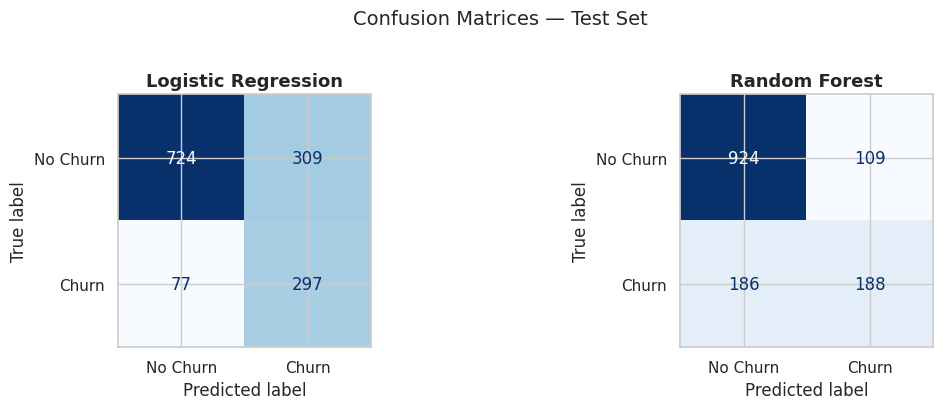

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, model, preds, title in zip(
    axes,
    [lr_model, rf_model],
    [lr_preds, rf_preds],
    ["Logistic Regression", "Random Forest"]
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontsize=13, fontweight="bold")

plt.suptitle("Confusion Matrices — Test Set", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

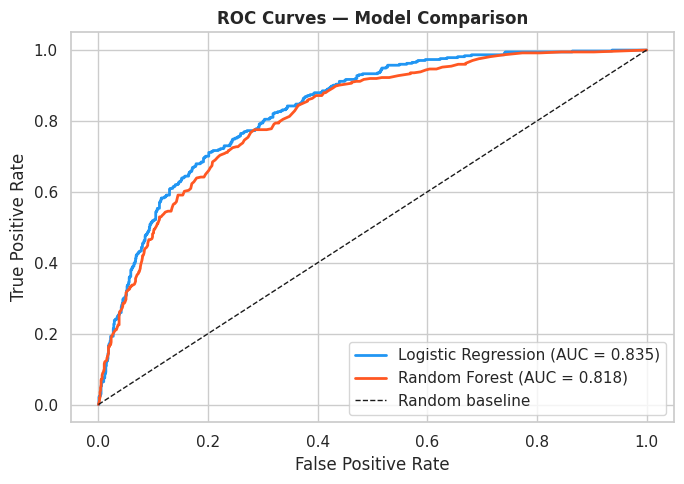

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))

for proba, label, color in [
    (lr_proba, "Logistic Regression", "#2196F3"),
    (rf_proba, "Random Forest", "#FF5722"),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{label} (AUC = {auc_score:.3f})", color=color, linewidth=2)

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random baseline")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Model Comparison", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## Cross-Validation
A single train/test split can be lucky or unlucky. Cross-validation gives a more reliable estimate of real-world performance by averaging over 5 folds.

In [17]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Wrap each model in a pipeline with the scaler so CV folds are scaled correctly.
# Passing raw X to cross_val_score would skip scaling and cause convergence warnings.
lr_pipeline = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
rf_pipeline = make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1))

for pipeline, name in [(lr_pipeline, "Logistic Regression"), (rf_pipeline, "Random Forest")]:
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring="roc_auc")
    print(f"{name}  |  CV ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression  |  CV ROC-AUC: 0.8449 ± 0.0027
Random Forest  |  CV ROC-AUC: 0.8276 ± 0.0040


## Feature Importance
Which features actually drive churn predictions?

- **Logistic Regression**: Top positive/negative coefficients (log-odds)
- **Random Forest**: Mean decrease in impurity across trees

These connect our model back to the business recommendations.

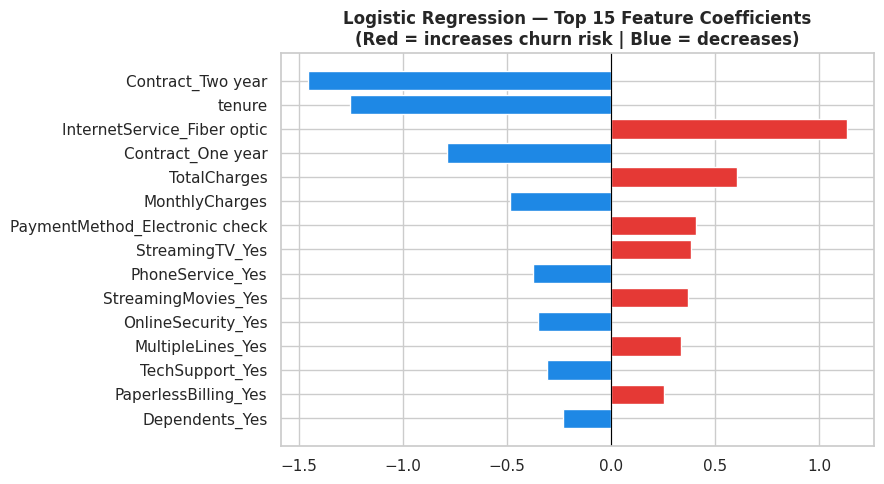

In [18]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#E53935" if c > 0 else "#1E88E5" for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Logistic Regression — Top 15 Feature Coefficients\n(Red = increases churn risk | Blue = decreases)", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

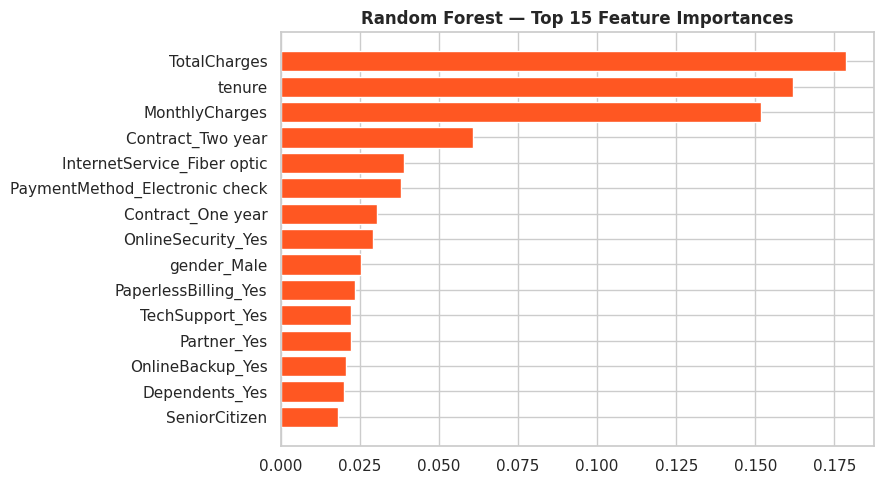

In [19]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(importance_df["Feature"], importance_df["Importance"], color="#FF5722")
ax.set_title("Random Forest — Top 15 Feature Importances", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Business Insights (Model-Grounded)
Findings are now directly supported by model evidence, not just EDA observations.

In [20]:
top_churn_drivers     = coef_df[coef_df["Coefficient"] > 0].head(5)
top_retention_factors = coef_df[coef_df["Coefficient"] < 0].head(5)

print("TOP CHURN DRIVERS (Logistic Regression — positive coefficients):")
print(top_churn_drivers[["Feature", "Coefficient"]].to_string(index=False))

print("\nTOP RETENTION FACTORS (negative coefficients — reduce churn risk):")
print(top_retention_factors[["Feature", "Coefficient"]].to_string(index=False))


TOP CHURN DRIVERS (Logistic Regression — positive coefficients):
                       Feature  Coefficient
   InternetService_Fiber optic     1.134813
                  TotalCharges     0.606596
PaymentMethod_Electronic check     0.411009
               StreamingTV_Yes     0.386970
           StreamingMovies_Yes     0.371653

TOP RETENTION FACTORS (negative coefficients — reduce churn risk):
          Feature  Coefficient
Contract_Two year    -1.456973
           tenure    -1.253034
Contract_One year    -0.788478
   MonthlyCharges    -0.485947
 PhoneService_Yes    -0.373091


##Key model-grounded findings:

1. CONTRACT TYPE: Month-to-month contract is among the strongest predictors of churn.
   Two-year contracts are a major retention factor (large negative coefficient).
   → Business action: Incentivise longer contracts with discounts or perks.

2. TENURE: Strong negative relationship with churn — longer-tenured customers are
   significantly less likely to leave.
   → Business action: Invest heavily in early-lifecycle retention (months 1–6).

3. PAYMENT METHOD: Electronic check is positively associated with churn.
   Automatic payment methods (bank transfer, credit card) correlate with retention.
   → Business action: Promote auto-pay enrollment, especially at onboarding.

4. INTERNET SERVICE — FIBER OPTIC: Associated with higher churn, possibly reflecting
   price sensitivity or unmet quality expectations.
   → Business action: Investigate satisfaction among fiber customers specifically.
""")